## 12.05 多尺度目标检测


### 环境配置


In [3]:
import os, sys
sys.path.insert(0, "..")
os.environ["TILE_FWK_DEVICE_ID"] = "1"
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    import pypto
    import torch
    import torch_npu
    import torchvision
    from torch import nn
    from torch.nn import functional as F
    from src.D2LFunction import *

import logging
# pypto 导入会把根 logger 调到 DEBUG，压回 WARNING 避免刷屏
logging.getLogger().setLevel(logging.WARNING)
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("PIL").setLevel(logging.WARNING)

device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"


---


### 练习 12.5.1

**题目：** 根据我们在 [7.1节](../07_pypto_modern_convolutional_networks/07.01_alexnet.ipynb)中的讨论，深度神经网络学习图像特征级别抽象层次，随网络深度的增加而升级。在多尺度目标检测中，不同尺度的特征映射是否对应于不同的抽象层次？为什么？

**解答：**

&emsp;&emsp;是的。在多尺度目标检测中，不同尺度的特征映射通常对应于不同的抽象层次，这是因为不同尺度的特征提取器在网络中的位置不同，而网络层数直接决定特征提取器的感受野大小：

- 浅层的特征提取器感受野较小，提取图像的低级特征，如边缘、纹理等；
- 随着网络加深，感受野逐渐扩大，能够涵盖更大范围的图像结构与语义信息，提取更高级的特征，如物体的形状、部件等。

&emsp;&emsp;因此较浅层的特征映射对应较低级的抽象层次，较深层的特征映射对应较高级的抽象层次。多尺度特征映射组合可以有效捕捉目标在不同尺度上的表征与上下文信息，从而提高目标检测性能。

---


### 练习 12.5.2

**题目：** 在 [12.5.1节](./12.05_multiscale_object_detection.ipynb)中的实验里的第一个尺度（`fmap_w=4, fmap_h=4`）下，生成可能重叠的均匀分布的锚框。

**解答：**

&emsp;&emsp;在正文第一个尺度下（特征图$4\times 4$、`s=[0.15]`），锚框互不重叠；通过调整`display_anchors`中的`s`参数（例如增大到0.25），锚框会变大并相互重叠。

以下使用 `torch` 编程进行验证：


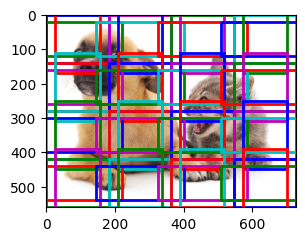

In [8]:
set_figsize()
img = plt.imread('../images/catdog.jpg')
h, w = img.shape[:2]

def display_anchors(fmap_w, fmap_h, s):
    fmap = torch.zeros((1, 10, fmap_h, fmap_w))
    anchors = multibox_prior(fmap, sizes=s, ratios=[1, 2, 0.5])
    bbox_scale = torch.tensor((w, h, w, h))
    show_bboxes(plt.imshow(img).axes, anchors[0] * bbox_scale)

# s=0.15 时锚框不重叠；增大 s 使锚框重叠
display_anchors(fmap_w=4, fmap_h=4, s=[0.25])

&emsp;&emsp;与正文 `s=[0.15]`（互不重叠）对比，`s=[0.25]` 时相邻锚框相互重叠，这对应较大目标的检测：重叠的锚框意味着多个锚框可能命中同一目标，需要靠非极大值抑制去重。

使用 `PyPTO` 编程进行验证（`src/PyPTOAnchor.py` 的 `multibox_prior` kernel）：


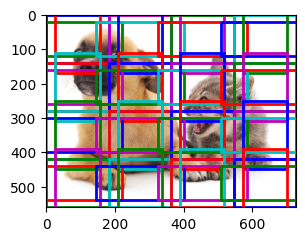

In [10]:
from src.PyPTOAnchor import multibox_prior as mb_prior_pypto

# PyPTO kernel 的类型注解为 (1, 3, H, W)，锚框只依赖 H/W，前两维不影响输出
fmap = torch.zeros((1, 3, 4, 4), device=device)
anchors_pt = mb_prior_pypto(fmap, sizes=[0.25], ratios=[1, 2, 0.5])
bbox_scale = torch.tensor((w, h, w, h))
fig = plt.imshow(img)
show_bboxes(fig.axes, anchors_pt.cpu()[0] * bbox_scale);

---


### 练习 12.5.3

**题目：** 给定形状为$1 \times c \times h \times w$的特征图变量，其中$c$、$h$和$w$分别是特征图的通道数、高度和宽度。怎样才能将这个变量转换为锚框类别和偏移量？输出的形状是什么？

**解答：**

&emsp;&emsp;设每个像素生成$a$个锚框，目标类别数量为$q$，则锚框类别数量为$q+1$（第0类是背景），每个锚框对应4个偏移量。

- **锚框类别**：先用$1\times 1$卷积把特征图通道数变为$a \times (q+1)$，再做形状变换：
$$(1, a \times (q+1), h, w) \longrightarrow (1, h \times w \times a \times (q+1)) \longrightarrow (1, h \times w \times a, q+1)$$
- **偏移量**：先用$1\times 1$卷积把特征图通道数变为$4 \times a$，再做形状变换：
$$(1, 4 \times a, h, w) \longrightarrow (1, h \times w \times a \times 4)$$

以下使用 `torch` 编程进行验证：


In [13]:
def cls_predictor(num_inputs, num_anchors, num_classes):
    return nn.Conv2d(num_inputs, num_anchors * (num_classes + 1), kernel_size=1)

def bbox_predictor(num_inputs, num_anchors):
    return nn.Conv2d(num_inputs, num_anchors * 4, kernel_size=1)

def flatten_pred(pred):
    return torch.flatten(pred.permute(0, 2, 3, 1), start_dim=1)

X = torch.zeros((1, 8, 20, 20))
num_classes = 10
sizes, ratios = [0.2, 0.272, 0.37], [1, 2, 0.5]
num_anchors = len(sizes) + len(ratios) - 1   # a = 3 + 3 - 1 = 5

cls_preds = flatten_pred(cls_predictor(8, num_anchors, num_classes)(X))
cls_preds = cls_preds.reshape(cls_preds.shape[0], -1, num_classes + 1)
bbox_preds = flatten_pred(bbox_predictor(8, num_anchors)(X))
print('锚框类别形状:', cls_preds.shape)
print('偏移量形状  :', bbox_preds.shape)

锚框类别形状: torch.Size([1, 2000, 11])
偏移量形状  : torch.Size([1, 8000])


&emsp;&emsp;从结果可以看出：给定$(1, 8, 20, 20)$特征图、10个类别、$a=5$个锚框，锚框类别的形状为$(1, 20 \times 20 \times 5, 11) = (1, 2000, 11)$，偏移量的形状为$(1, 20 \times 20 \times 5 \times 4) = (1, 8000)$。

---
## 参考答案来源
参考答案和 PyTorch 代码实现来源：[https://datawhalechina.github.io/d2l-ai-solutions-manual/#/](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/)
